# Tugas Machine Learning
## Topik: Sampling dan Exploratory Data Analysis (EDA)
Dataset: Iris

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

plt.style.use('default')

In [13]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map(dict(enumerate(iris.target_names)))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# BAGIAN A – Eksplorasi Data Awal

# 1. Informasi Dataset

In [14]:
df.shape

(150, 5)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [16]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

#### Informasi Dataset

Dataset Iris memiliki 150 data dan 5 variabel.
Terdiri dari 4 variabel numerik dan 1 variabel kategori (species).
Jumlah masing-masing spesies adalah 50 sehingga dataset bersifat seimbang.

## 2. Statistik Deskriptif

In [17]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [18]:
df.median(numeric_only=True)

sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
dtype: float64


Berdasarkan statistik deskriptif:
- Variabel petal length memiliki rata-rata sekitar 3.75 cm.
- Rentang nilai terbesar terdapat pada petal length.
- Standar deviasi menunjukkan variasi terbesar pada petal length.

## 3. Visualisasi Distribusi

a. Histogram

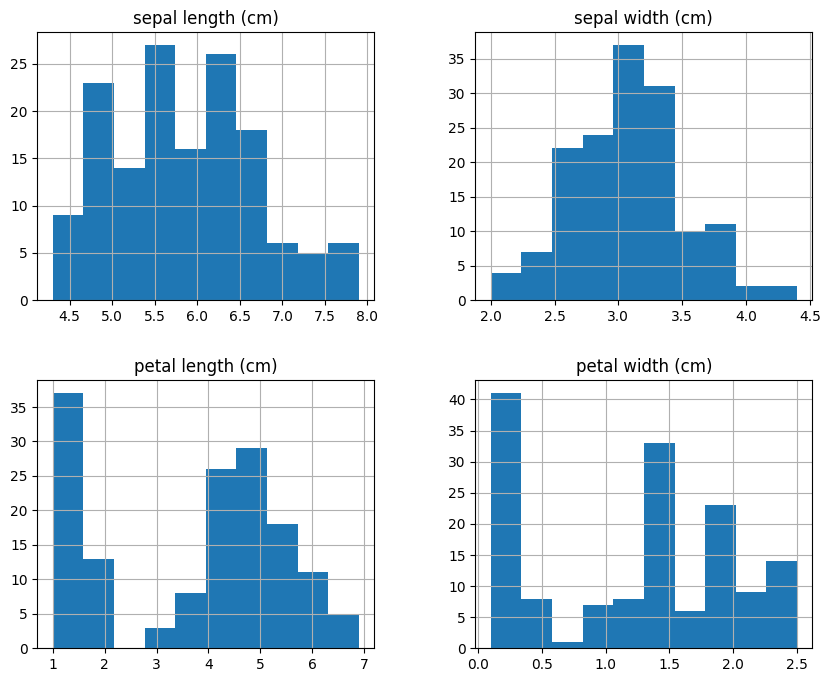

In [19]:
df.hist(figsize=(10,8))
plt.show()

Distribusi sepal length dan sepal width cenderung mendekati normal.
Petal length dan petal width menunjukkan pemisahan yang cukup jelas antar spesies.
Tidak terlihat distribusi yang sangat miring ekstrem.

b. Boxplot untuk setiap variabel numerik

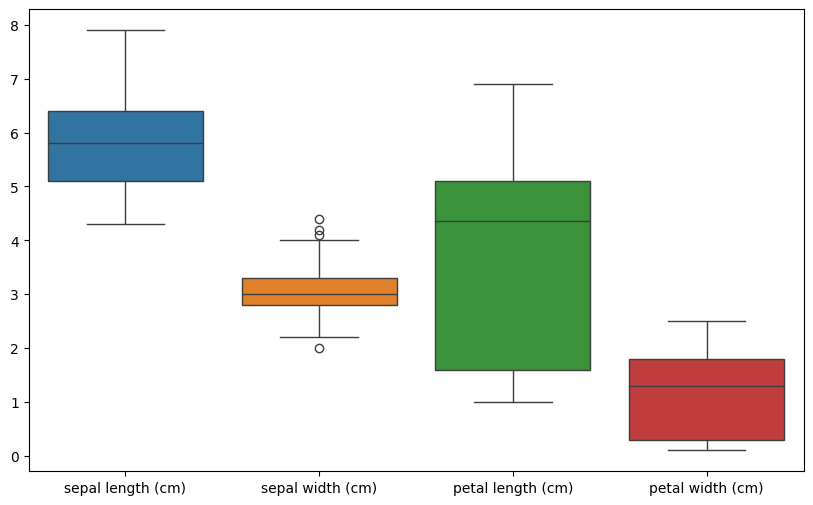

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.iloc[:,:4])
plt.show()

Petal length memiliki rentang nilai paling besar.
Sebaran data cukup baik dan tidak terlihat outlier ekstrem yang signifikan.
Variabilitas terbesar terdapat pada petal length.

## 4. Visualisasi Berdasarkan Spesies

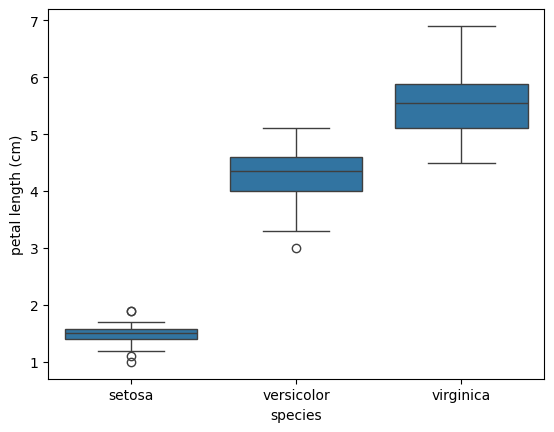

In [21]:
sns.boxplot(x='species', y='petal length (cm)', data=df)
plt.show()

Setosa memiliki petal length paling kecil dan terpisah jelas dari spesies lainnya.
Versicolor berada di tengah.
Virginica memiliki petal length paling besar.
Petal length merupakan variabel paling efektif untuk membedakan spesies.

## BAGIAN B - Sampling (Bootstrap)

### 1. Bootstrap Tunggal

In [22]:
data = df['petal length (cm)']
n = len(data)

In [23]:
bootstrap_sample = np.random.choice(data, size=n, replace=True)

print("Mean Bootstrap:", np.mean(bootstrap_sample))
print("Median Bootstrap:", np.median(bootstrap_sample))
print("Mean Asli:", np.mean(data))
print("Median Asli:", np.median(data))

Mean Bootstrap: 3.6360000000000006
Median Bootstrap: 4.2
Mean Asli: 3.7580000000000005
Median Asli: 4.35



Mean bootstrap mendekati mean data asli karena bootstrap mengambil sampel dari distribusi yang sama dengan pengembalian.

### 2. Bootstrap Berulang

In [28]:
def bootstrap_mean(data, n_bootstrap):
    means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return means

means_100 = bootstrap_mean(data, 100)
means_1000 = bootstrap_mean(data, 1000)
means_10000 = bootstrap_mean(data, 10000)

### 3. Visualisasi Hasil Bootstrap

### a. Histogram distribusi mean bootstrap

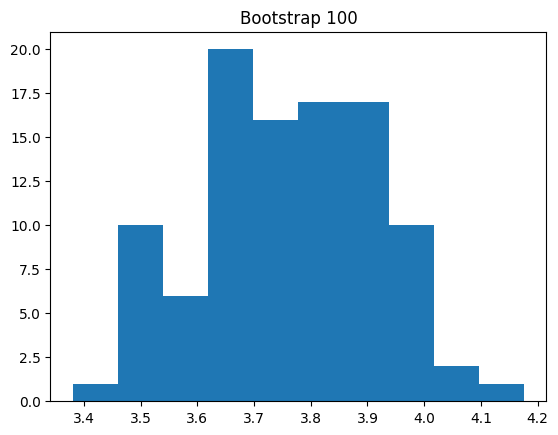

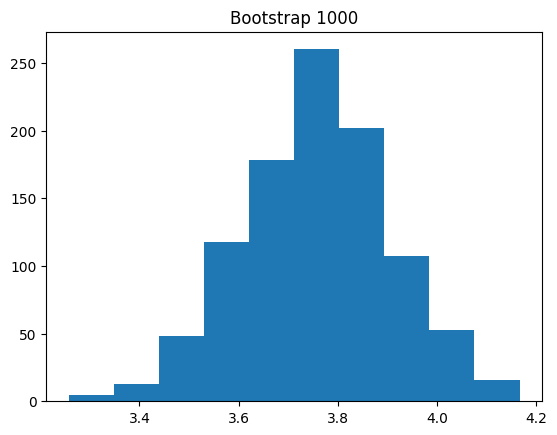

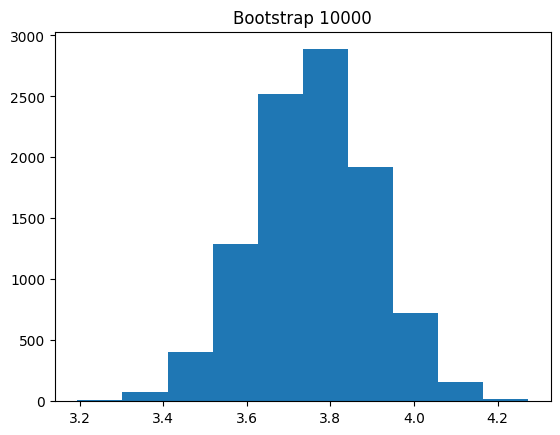

In [25]:
plt.hist(means_100)
plt.title("Bootstrap 100")
plt.show()

plt.hist(means_1000)
plt.title("Bootstrap 1000")
plt.show()

plt.hist(means_10000)
plt.title("Bootstrap 10000")
plt.show()


Histogram menunjukkan distribusi dari rata-rata (mean) hasil bootstrap.
1. Pada bootstrap 100:
Distribusi masih terlihat agak kasar dan belum terlalu halus karena jumlah sampel bootstrap masih sedikit.
2. Pada bootstrap 1000:
Distribusi mulai terlihat lebih halus dan lebih mendekati bentuk normal.
3. Pada bootstrap 10000:
Distribusi semakin halus, simetris, dan stabil. Ini menunjukkan bahwa semakin banyak pengulangan bootstrap, estimasi distribusi sampling semakin baik.

Secara umum, distribusi mean bootstrap cenderung mendekati distribusi normal sesuai dengan Central Limit Theorem.

### b. Boxplot mean boostrap

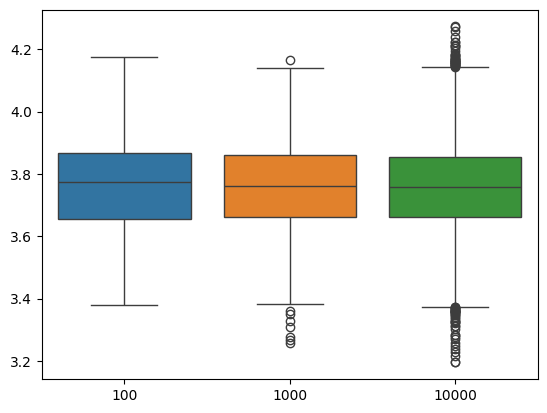

In [26]:
sns.boxplot(data=[means_100, means_1000, means_10000])
plt.xticks([0,1,2], ['100','1000','10000'])
plt.show()

Boxplot menunjukkan penyebaran nilai mean dari masing-masing jumlah bootstrap.
1. Bootstrap 100:
Sebaran masih relatif lebih lebar dan variasinya lebih besar.
2. Bootstrap 1000:
Sebaran mulai menyempit dan lebih konsisten.
3. Bootstrap 10000:
Sebaran paling stabil dan paling sempit, menunjukkan estimasi mean yang lebih presisi.

Semakin besar jumlah bootstrap, variabilitas estimasi mean semakin kecil dan hasil menjadi lebih stabil.

## 4. Interval Kepercayaan 95%

In [27]:
print("CI 100:", np.percentile(means_100, [2.5, 97.5]))
print("CI 1000:", np.percentile(means_1000, [2.5, 97.5]))
print("CI 10000:", np.percentile(means_10000, [2.5, 97.5]))

CI 100: [3.50031667 4.0224    ]
CI 1000: [3.46193333 4.05206667]
CI 10000: [3.474 4.04 ]


Interval kepercayaan dihitung menggunakan metode persentil (2.5% dan 97.5%).
1. Bootstrap 100:
Interval masih cukup lebar karena jumlah pengulangan sedikit.
2. Bootstrap 1000:
Interval mulai stabil dan lebih konsisten.
3. Bootstrap 10000:
Interval paling stabil dan relatif konstan.

Semakin banyak jumlah bootstrap, estimasi interval kepercayaan menjadi lebih akurat dan stabil.
Mean data asli berada di dalam interval kepercayaan tersebut, yang menunjukkan bahwa estimasi bootstrap valid.

## BAGIAN C -- Perbandingan dan Analisis

### 1. Apakah mean bootstrap mendekati mean data asli?

Ya, mean bootstrap cenderung mendekati mean data asli. Hal ini terjadi karena bootstrap mengambil sampel dari data yang sama dengan metode *sampling with replacement*. Karena sumber datanya sama, distribusi sampling yang dihasilkan oleh bootstrap akan meniru distribusi asli. Oleh sebab itu, rata-rata dari banyak sampel bootstrap akan berkumpul di sekitar mean data asli. Semakin banyak jumlah bootstrap dilakukan, estimasi mean menjadi semakin mendekati nilai mean sebenarnya sesuai dengan prinsip *Law of Large Numbers*.


### 2. Bagaimana perubahan distribusi saat jumlah bootstrap bertambah?

Ketika jumlah bootstrap masih kecil (misalnya 100), distribusi mean terlihat lebih kasar dan penyebarannya lebih lebar. Saat jumlah bootstrap meningkat menjadi 1000, distribusi mulai terlihat lebih halus dan simetris. Pada 10000 bootstrap, distribusi menjadi sangat halus dan semakin mendekati distribusi normal. Hal ini terjadi karena semakin banyak pengulangan, estimasi distribusi sampling menjadi lebih stabil dan akurat. Sesuai dengan *Central Limit Theorem*, distribusi rata-rata sampel akan cenderung berbentuk normal ketika jumlah sampel cukup besar.


### 3. Mana yang lebih stabil: 100, 1000, atau 10000?

Bootstrap 10000 adalah yang paling stabil. Pada bootstrap 100, variasi antar pengulangan masih cukup besar sehingga hasil dapat berubah jika dijalankan ulang. Pada bootstrap 1000, hasil sudah cukup stabil dan variasinya mulai mengecil. Pada bootstrap 10000, distribusi mean sangat konsisten dan perubahan antar percobaan sangat kecil. Semakin besar jumlah bootstrap, variabilitas estimasi semakin kecil dan hasil semakin presisi.


### 4. Apakah mean asli berada dalam interval kepercayaan?

Ya, mean asli berada di dalam interval kepercayaan 95%. Hal ini menunjukkan bahwa metode bootstrap berhasil mengestimasi distribusi sampling dengan baik. Interval kepercayaan yang dihitung menggunakan persentil 2.5% dan 97.5% memberikan rentang nilai yang secara statistik kemungkinan besar mengandung mean populasi sebenarnya. Jika mean asli berada di dalam interval tersebut, maka estimasi bootstrap dapat dianggap valid dan tidak bias secara signifikan.


### 5. Mengapa satu data bisa muncul berkali-kali pada bootstrap?

Hal ini terjadi karena bootstrap menggunakan metode *sampling with replacement* (dengan pengembalian). Artinya, setiap kali satu data dipilih, data tersebut dikembalikan lagi ke dalam populasi sebelum pemilihan berikutnya dilakukan. Akibatnya, satu nilai dapat terpilih lebih dari satu kali dalam satu sampel bootstrap, sementara nilai lain bisa saja tidak terpilih sama sekali. Metode ini digunakan untuk mensimulasikan distribusi sampling tanpa perlu mengambil sampel baru dari populasi asli.

# BAGIAN D – Kesimpulan

• Insight utama dari EDA dataset Iris  
Dataset Iris terdiri dari 150 data dengan 4 variabel numerik dan 3 spesies yang jumlahnya seimbang. Variabel petal length dan petal width merupakan variabel yang paling membedakan antar spesies. Distribusi data relatif baik dan tidak terdapat outlier ekstrem yang signifikan.

• Karakteristik tiap spesies (berdasarkan visualisasi)  
Setosa memiliki ukuran petal paling kecil dan terpisah jelas dari spesies lainnya. Versicolor memiliki ukuran sedang dan berada di antara setosa dan virginica. Virginica memiliki ukuran petal paling besar. Petal length menjadi variabel paling efektif dalam membedakan ketiga spesies tersebut.

• Manfaat bootstrap dalam analisis data  
Bootstrap membantu mengestimasi distribusi sampling dan interval kepercayaan tanpa perlu asumsi distribusi normal. Metode ini memungkinkan perhitungan estimasi parameter statistik hanya berdasarkan data yang tersedia melalui teknik resampling dengan pengembalian.

• Jumlah bootstrap yang menurut Anda cukup  
Berdasarkan hasil percobaan, 1000 bootstrap sudah cukup stabil untuk menghasilkan estimasi yang konsisten. Namun, 10000 bootstrap memberikan hasil yang lebih presisi dan lebih minim variasi.